# 065. next character 를 예측하여 Shakespeare Sonnet Text 생성

- 순환 신경망을 활용한 문자열 생성



- character 단위로 text 생성  

    - 문자 시퀀스 (ex. "Shakespear")가 주어지면, 시퀀스의 다음 문자("e")를 예측하는 모델을 훈련
    - 모델을 반복하여 호출하면 더 긴 텍스트 시퀀스 생성이 가능
    - 훈련이 시작되었을 때, 이 모델은 영어 단어의 철자를 모르거나 심지어 텍스트의 단위가 단어라는 것도 모름 
    
    
- google NLP tutorial 참조

In [1]:
import tensorflow as tf
import numpy as np
import time
print(tf.__version__)

2.2.0


# Text File download

- 셰익스피어 데이터셋 다운로드  


- data 는 ~/.keras/dataset 에 저장. absolute path 지정해 주어야 replace  됨. 다시 download 받을 경우 ~/.keras file 삭제 필요

In [2]:
# path_to_file = tf.keras.utils.get_file("shakespeare.txt", 
#                           "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt")

#path_to_file = tf.keras.utils.get_file("young-prince.txt", 
#             "https://raw.githubusercontent.com/ironmanciti/NLP_Lecture/master/data/young_prince.txt")

path_to_file = tf.keras.utils.get_file("Alice_wonderland_Korean.txt", 
                "https://github.com/ironmanciti/NLP_Lecture/raw/master/data/Alice_wonderland_Korean.txt")


147456/144596 [==============================] - 0s 0us/step


In [5]:
#text = open(path_to_file, 'r').read()

text = open(path_to_file,"r", encoding='cp949').read()   # Alice_wonderland encoding
len(text)

84379

In [6]:
text

'앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요.\n그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화 하나 없는 책이지 뭐예요.\n‘그림도 대화도 없는데,’라고 앨리스는 생각했어요. ‘이런 책을 어따 쓴담?’\n그리하여 늘 그러하듯 앨리스는 자기만의 생각 속으로 빠져들었지요. 왜 있잖아요, 덥다 보면 잠도 밀려오고 약간 멍청해지는 그런 기분 말이에요. \n‘그래 데이지 화환(꽃 화환. 주이 아이들이 목걸이로 만듦)을 만들면 어떨까, 일어나 데이지(꽃)만 주우면 되잖아.’\n그때 분홍색 눈을 지닌 흰색 토끼 한 마리가 손살같이 그녀 옆을 지나쳐갔지 뭐예요.\n그게 놀랄 일은 아니었어요, 또한 그 토끼가 “이런! 이런! 늦겠는 걸!”라고 말하는 걸 들은 것도 하나도 놀랍진 않았어요. 하긴 그녀도 나중에 다시 생각해보니 좀 기이하긴 했었네요. 하지만 그땐 모든 게 자연스럽게 받아들여졌답니다.\n토끼는 자신의 조끼 호주머니에서 시계를 꺼내 보더니 더 서둘러 달려갔어요.\n앨리스도 뒤따랐어요. 왜냐면 문득 ‘그래 난 예전에 한 번도 조끼를 입거나 호주머니에서 시계를 꺼내 보는 토끼를 본 적이 없어.’라는 생각이 들면서 호기심이 사뭇 일었기 때문이죠.\n그녀는 토끼를 따라 들판을 뛰었어요, 그러다 우연히 산울타리 밑에 크게 나 있던 토끼 굴 속으로 그 토끼가 쏙 들어가버리는 걸 보았어요.\n뒤이어 앨리스도 거기로 뒤따라 들어갔답니다.\n어떻게 빠져나오지 하는 생각일랑은 안 들었거든요.\n한동안은 터널 같은 토끼굴이 곧장 이어져 있었어요. 그러다 뚝 하고 떨어졌지요. 그래도 머지않아 아주 깊은 우물 바닥으로 떨어질 거 같단 생각은 앨리스도 들었답니다.\n근데 우물이 깊은 걸까요 아님 앨리스가 떨어지는 속도가 느린 걸까요?, 한참을 내려갔다 싶은데도 계속 떨어지고 있었거든요. \n‘무슨 일이 벌어질까?’ 싶어 앨리스가 아래를 내려다봤어요.\n아래를 봐도 죄다 깜깜해 분간이 잘 되네요. 그래서 우물 양쪽을 봤더니 거긴 찬

In [7]:
print(text[:100])

앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요.
그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화 하나 없는 책이지 뭐예요.


# lookup table 작성

- 문자들을 숫자로 변환


- 두 개의 조회 테이블(lookup table) 작성  
    - character to index
    - index to character


- text 중에 포함된 character 들을 이용하여 charactet-to-index, index-to-character 변환 table 작성
    - 하나는 문자를 숫자에 매핑하고 다른 하나는 숫자를 문자에 매핑  
    - 문자를 0번 인덱스부터 고유 문자 길이까지 매핑

In [0]:
chars = sorted(set(text))
nb_chars = len(chars)

char2idx = dict((c, i) for i, c in enumerate(chars))
idx2char = chars

In [9]:
print("문자 갯수 : ", nb_chars)
print()
print("character to index lookup table : \n", char2idx)
print()
print("index to character lookup table : \n",idx2char)

문자 갯수 :  1093

character to index lookup table : 
 {'\n': 0, ' ': 1, '!': 2, '(': 3, ')': 4, '+': 5, ',': 6, '-': 7, '.': 8, '/': 9, '0': 10, '1': 11, '2': 12, '3': 13, '4': 14, '5': 15, '6': 16, '7': 17, '8': 18, '9': 19, ':': 20, '=': 21, '?': 22, 'C': 23, 'D': 24, 'E': 25, 'F': 26, 'I': 27, 'J': 28, 'K': 29, 'M': 30, 'Q': 31, 'R': 32, 'X': 33, 'Y': 34, '[': 35, ']': 36, 'a': 37, 'b': 38, 'c': 39, 'd': 40, 'e': 41, 'f': 42, 'g': 43, 'h': 44, 'i': 45, 'k': 46, 'l': 47, 'm': 48, 'n': 49, 'o': 50, 'p': 51, 'r': 52, 's': 53, 't': 54, 'u': 55, 'v': 56, 'w': 57, 'x': 58, 'y': 59, 'z': 60, '~': 61, 'ː': 62, '―': 63, '‘': 64, '’': 65, '“': 66, '”': 67, '…': 68, '←': 69, '→': 70, '▶': 71, '◆': 72, '○': 73, '♥': 74, 'ㄱ': 75, 'ㄴ': 76, 'ㄹ': 77, 'ㅀ': 78, 'ㅁ': 79, 'ㅂ': 80, 'ㅆ': 81, 'ㅈ': 82, 'ㅉ': 83, 'ㅋ': 84, 'ㅍ': 85, 'ㅛ': 86, 'ㅝ': 87, 'ㅡ': 88, 'ㅣ': 89, 'ㅤ': 90, '가': 91, '각': 92, '간': 93, '갇': 94, '갈': 95, '감': 96, '갑': 97, '값': 98, '갔': 99, '강': 100, '갖': 101, '같': 102, '갛': 103, '개': 104, '객': 10

### 훈련 sample 과 target 만들기 

- input data 를 고정길이로 통일하기 위해 MAX_SEQ_LEN 을 입력의 최대 길이로 지정 (임의로 결정)   


- MAX_SEQ_LEN 개의 연속된 character sequence 를 input 으로 하고, 1 character shift 하여 이어지는 동일한 길이의 character sequence 를 label 로 만든다.  

- 따라서, MAX_SEQ_LEN + 1 길이의 덩어리(chunk)로 text 를 분할하여 input, label 분리 (tf.Dataset method 사용)
        ex) MAX_SEQ_LEN = 4 인 경우,
            "Hell"  --> "ello"
            

- 이를 손쉽게 하기 위해 tensorflow 가 제공하는 tf.data.Dataset.from_tensor_slices 함수를 사용하여 text vector 를 character index 의 stream 으로 변환  

In [10]:
MAX_SEQ_LEN = 100         # time step = 100, 단일 입력에 대해 원하는 문장의 최대 글자수
examples_per_epoch = len(text) // MAX_SEQ_LEN
print("한 epoch 당 처리할 전체 sample 수 :", examples_per_epoch)

한 epoch 당 처리할 전체 sample 수 : 843


**char2index lookup table 을 이용하여 text 전체를 integer 로 변환**

In [11]:
text_as_int = np.array([char2idx[c] for c in text])
print(text_as_int)

[696 435 640 ... 286 291   8]


In [12]:
print("변환전 : {}, 변환후 : {}".format(text[:13], text_as_int[:13]))

변환전 : 앨리스는 언니 옆에 앉아, 변환후 : [696 435 640 281   1 708 286   1 733 720   1 684 681]


# 훈련 sample 및 target 만들기

- tf.data.Dataset.from_tensor_slices method $\rightarrow$ 주어진 tensor 들을 first dimension 을 따라 slice

In [13]:
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
char_dataset

<TensorSliceDataset shapes: (), types: tf.int64>

In [14]:
seq = [idx.numpy() for idx in char_dataset.take(5)]
print(seq)
print([''.join(idx2char[i]) for i in seq])

[696, 435, 640, 281, 1]
['앨', '리', '스', '는', ' ']


  ## dataset 생성 - input text, target text

**tf.data 의 batch method 를 사용하면 개별 character 를 원하는 size 의 character sequence 로 쉽게 바꿀 수 있다**

- char_dataset 을 seq_len +1 길이의 character sequence 로 변환 (next character 를 예측하는 문제이므로 +1) 하여  
  [ : sequence]는 input 으로 사용하고 [1 : sequence+1] 은 label 로 사용  
  

- sequnces 를 입력 text 와 target text 로 분리하는 helper 함수를 작성하여 map 함수로 각 sequences 의 element 에 적용

In [0]:
# sequence 를 input, target 으로 분리
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

In [16]:
dataset = char_dataset.batch(MAX_SEQ_LEN + 1, drop_remainder=True)
dataset = dataset.map(split_input_target)

input, target = next(iter(dataset))
input_seq  = [i for i in input.numpy()]
target_seq = [i for i in target.numpy()]
print(input_seq)
print(target_seq)
print("입력 data   = ", repr(''.join(idx2char[idx] for idx in input_seq)))
print("출력 data   = ", repr(''.join(idx2char[idx] for idx in target_seq)))

[696, 435, 640, 281, 1, 708, 286, 1, 733, 720, 1, 684, 681, 1, 1037, 787, 1, 714, 784, 1, 100, 328, 720, 1, 684, 681, 792, 281, 1, 118, 1, 849, 424, 1042, 849, 171, 1, 647, 797, 1044, 706, 755, 8, 0, 163, 398, 291, 1, 1036, 327, 1, 519, 1, 708, 286, 91, 1, 788, 132, 1, 792, 281, 1, 890, 720, 1, 274, 173, 779, 1, 836, 171, 317, 1, 1044, 849, 445, 1, 163, 439, 784, 227, 1, 304, 1062, 1, 1034, 227, 1, 714, 281, 1, 890, 784, 849, 1, 489, 734, 755, 8]
[435, 640, 281, 1, 708, 286, 1, 733, 720, 1, 684, 681, 1, 1037, 787, 1, 714, 784, 1, 100, 328, 720, 1, 684, 681, 792, 281, 1, 118, 1, 849, 424, 1042, 849, 171, 1, 647, 797, 1044, 706, 755, 8, 0, 163, 398, 291, 1, 1036, 327, 1, 519, 1, 708, 286, 91, 1, 788, 132, 1, 792, 281, 1, 890, 720, 1, 274, 173, 779, 1, 836, 171, 317, 1, 1044, 849, 445, 1, 163, 439, 784, 227, 1, 304, 1062, 1, 1034, 227, 1, 714, 281, 1, 890, 784, 849, 1, 489, 734, 755, 8, 0]
입력 data   =  '앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요.\n그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화

# Training / Target dataset 구성

- input_sample 의 각 인덱스는 하나의 타임 스텝(time step)으로 처리  

 
- 위의 경우, time step 0 의 입력으로 모델은 "F"의 인덱스를 받고 다음 문자로 "i"의 인덱스를 예측   


- 다음 타임 스텝에서도 같은 일을 하지만 RNN은 현재 입력 문자 외에 이전 타임 스텝의 컨텍스트(context)를 고려하여 예측  


- RNN 의 context 정보는 hidden state 를 뜻함  


- 이전 batch 의 context 정보를 다음 batch 의 initial hidden state 로 받기 위해 RNN model 정의 시 stateful=True 로 지정

## Training batch 생성

- tf.data를 사용하여 train batch 생성    


- 이 데이터를 모델에 넣기 전에 데이터를 섞은 후 배치를 만든다 (다음 character 를 예측하는 모델이고 임의의 batch size 로 잘랐으므로 shuffle 필요)  


- batch method 를 이용하여 train batch 생성

In [17]:
BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
dataset

<BatchDataset shapes: ((64, 100), (64, 100)), types: (tf.int64, tf.int64)>

## Model 생성

- Many-to-Many type

<div>
<img src="https://tensorflow.org/tutorials/text/images/text_generation_training.png", width="600">
</div>

- tf.keras.Sequential model 사용  


- 3 개의 층을 사용하여 모델 정의  


    1. Embedding : 입력층, embedding_dim 차원 벡터에 각 문자의 정수 코드를 매핑하는 훈련가능한 검색 table
        - 각 character 에 대해 model 은 embedding 을 검색하고, embedding 을 입력으로 하여 GRU(LSTM) 를 1 개의 time step 으로 실행  

    2. LSTM (GRU) 를 이용한 RNN 층

    3. 완전연결층(Dense) 
        - logits 생성 : (64, 100, 65) - (batch size, MAX_SEQ_LEN, vocab_size)


- Dense layer 에서 생성된 크기가 vocab_size 인 logit 을 tf.random.categorical 에 적용하여 다음 문자의 확률분포 예측  


- stateful=True 로 지정 - 문장이 계속 연속되므로 이전 batch 의 hidden state 를 다음번 batch 의 초기 state 로 사용  


- batch_input_shape 반드시 지정 ($t_i$ 의 initial state 가 $t_{i+bs}$ 로 연결되므로)


- 입력 batch shape : (64, 100)  
- 출력 batch shape : (64, 100, 65)

In [18]:
EMBEDDING_DIM = 256
RNN_UNITS = 1024
print(nb_chars)

1093


**마지막 Dense layer 의 activation='linear' --> shape(100, 65) 의 logit 생성**

- last layer 의 activation 을 softmax 로 하는 것보다 계산상 안정적임

In [0]:
def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, embedding_dim, batch_input_shape=[batch_size, None]),
        tf.keras.layers.LSTM(rnn_units, 
                             return_sequences=True, 
                             stateful=True,
                             recurrent_initializer='glorot_uniform'),
        tf.keras.layers.Dense(nb_chars)   # linear activation (logit 생성)
    ])
    return model

model = build_model(vocab_size=nb_chars, embedding_dim=EMBEDDING_DIM, rnn_units=RNN_UNITS, batch_size=BATCH_SIZE)

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (64, None, 256)           279808    
_________________________________________________________________
lstm (LSTM)                  (64, None, 1024)          5246976   
_________________________________________________________________
dense (Dense)                (64, None, 1093)          1120325   
Total params: 6,647,109
Trainable params: 6,647,109
Non-trainable params: 0
_________________________________________________________________


# 모델 훈련
- 이 문제는 표준적인 분류 문제로 취급 가능  


- 이전 RNN 상태와 현재 타임 스텝(time step)의 입력으로 다음 문자의 클래스를 예측   


- stateful RNN
    - time step 0 의 이전 상태는 이전 batch 의 final step 을 이어 받으므로 stateful=True 지정

## 손실함수 지정

- tf.keras.losses.sparse_categorical_crossentropy 손실 함수 이용


    - categorical_crossentropy - one-hot-encoding  
        [1,0,0]
        [0,1,0]   
        [0,0,1]  
    - sparse_categorical_crossentropy - integer encoding
        1  
        2  
        3  


- 우리의 모델은 logit 을 출력으로 반환하므로 from_logits=True 로 setting 한다.
    --> softmax activation 보다 계산이 안정적 (Tensorflow document)

In [0]:
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

model.compile(loss=loss, optimizer='adam', metrics=['accuracy'])

## checkpoint 구성

- 훈련 중 checkpoint 저장

In [0]:
import os

checkpoint_dir = './training_checkpoints'
# 체크포인트 파일 이름
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}")

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_prefix, save_weights_only=True)

### Training
- 영문 Shakespear : 50 epoch 이상
- 한글 어린왕자 : 300 epoch 이상 (Colab 10 분 소요)
- 한글 이상한 나라의 앨리스 : 200 epoch 이상 (Colab 10 분 소요)

In [26]:
s = time.time()

history = model.fit(dataset, epochs=200, callbacks=[checkpoint_callback])

print(time.time() - s)

Epoch 1/2
13/13 [==============================] - 1s 72ms/step - loss: 0.0406 - accuracy: 0.9947
Epoch 2/2
13/13 [==============================] - 2s 163ms/step - loss: 0.0128 - accuracy: 1.0000
3.241821527481079


Text(0.5, 1.0, 'Loss')

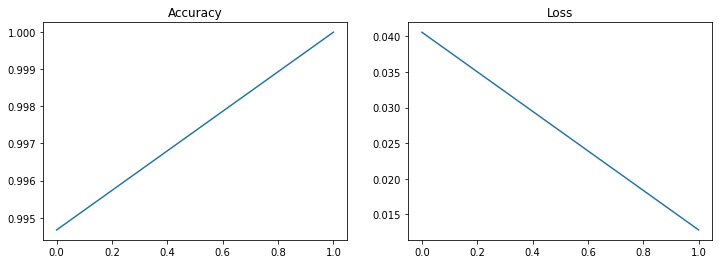

In [27]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'])
ax1.set_title('Accuracy')
ax2.plot(history.history['loss'])
ax2.set_title('Loss')

## 훈련된 model 을 이용한 text generation

- 예측 단계를 간단히 하기 위해 batch size = 1 로 변경한 새로운 model 을 rebuild 하고, last checkpoint 의 model weight 를 load  


- model rebuild 이유:

    - 우리가 작성했던 model 은 stateful=True 이므로, 작성 당시에 모델이 지정된 batch_input_shape 의  fixed batch size 만 받아 들인다.
    - 다른 batch size 에서도 수행되도록 하기 위해서는 model 을 batch_size 1 로 rebuild 하고 마지막 checkpoint 에서 저장한 model weight 를 restore

In [28]:
# batch size 1 의 new model
model = build_model(vocab_size=nb_chars, embedding_dim=EMBEDDING_DIM, rnn_units=RNN_UNITS, batch_size=1)
# weight load
model.load_weights(tf.train.latest_checkpoint(checkpoint_dir))
# batch size 1 로 rebuild
model.build(tf.TensorShape([1, None]))

model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (1, None, 256)            279808    
_________________________________________________________________
lstm_1 (LSTM)                (1, None, 1024)           5246976   
_________________________________________________________________
dense_1 (Dense)              (1, None, 1093)           1120325   
Total params: 6,647,109
Trainable params: 6,647,109
Non-trainable params: 0
_________________________________________________________________


## 마지막 layer 에서 output sampling 요령

- distribution 의 argmax 를 하면 model 이 쉽게 loop 에 빠짐.  


- tf.random.categorical(logits, num_samples) 을 이용하여 categorical 분포로 부터 sample 추출  


    - logits: [batch_size, num_classes] 의 2-D Tensor. 각 slice [i, :] 는 각 class 의 normalize 되지 않은 log-probability 를 나타냄
    - num_samples: 각 row slice 에서 추출할  독립적 sample 수
    
- MAX_SEQ_LEN=100 이므로, 100 개의 timestep 별로 65 개의 character 별 확률([100, 65) 로  1 개를 random sampling 
  --> output shape [100, 1]

In [29]:
ex_batch_predictions = np.random.random((1, 10, 65))   # (batch_size, time_steps, num_chars)
# 10 개 timestep 별로 (10, 65) shape 의 확률
tf.random.categorical(ex_batch_predictions[0], num_samples=1)

<tf.Tensor: shape=(10, 1), dtype=int64, numpy=
array([[35],
       [60],
       [13],
       [ 8],
       [21],
       [28],
       [ 5],
       [19],
       [12],
       [36]])>

## 예측 loop 

### 다음 code block 에서 text 생성:

- start string 으로 시작, RNN state 초기화 및 생성할 characters 수 설정 

- start string 과 RNN state 를 이용하여 next character 의 prediction 분포를 가져옴  

- categorical 분포를 이용하여 예측된 character 의 index 계산. 예측된 character 를 model 의 next input 으로 사용  

- model 에서 반환된 RNN state 는 model 로 다시 되돌려져서 이제는 하나의 character 가 아닌 더 많은 문맥(context) 에 더해짐

- 다음 단어를 예측한 후 수정된 RNN state 가 다시 모델로 피드백되어 더 많은 context 를 얻으며 학습되는 방식임

![텍스트를 생성하기 위해 모델의 출력이 입력으로 피드백](https://tensorflow.org/tutorials/text/images/text_generation_sampling.png)

In [33]:
# start_string = "ROMEO: "
#start_string = "여섯 살 적에"
start_string = "앨리스는 언니 옆에"

num_generate = 1000   # 생성할 문자의 수

# starting_string 의 숫자화 (벡터화)
input_eval = [char2idx[c] for c in start_string]
input_eval = tf.expand_dims(input_eval, 0)
input_eval

<tf.Tensor: shape=(1, 10), dtype=int32, numpy=array([[696, 435, 640, 281,   1, 708, 286,   1, 733, 720]], dtype=int32)>

### stateful RNN 이므로 새로운 text generation 을 위해 reset_states() method 를 이용하여 initial state 초기화

In [0]:
text_generated = []

model.reset_states()   # initial state

for i in range(num_generate):
    predictions = model(input_eval)    
    # batch dimension 제거
    predictions = tf.squeeze(predictions, 0)  
    # greedy(argmax) 하지 않도록 분포에서 sampling
    predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy() # scalar
    
    #print(predictions.shape)
    # predicted = tf.random.categorical(predictions, num_samples=1)
    # print(predicted)
    # print(predicted[-1, 0])
    # break
    
    # 예측된 character 를 이전 은닉 상태와 함께 다음 입력으로 model 에 전달
    input_eval = tf.expand_dims([predicted_id], 0)   
    text_generated.append(idx2char[predicted_id])

In [35]:
print(start_string + ''.join(text_generated))

앨리스는 언니 옆에 앉아 할일 없이 고양이야 말을 치기 시작했어요. “다들 사람들도 하나도 없이,”라며 겨울잠쥐가 말했어요. “…우물 안에 살았더랬지요?”
“자넨 정말 날 하신다니까,”라며 하인이 대꾸했어요. “여기 앉아 있을 게다…”
그 순간 집 문이 벌컥 열리더니 큰 접시가 날아오더니 하인은 어째 밖에 있던 거예요.
그녀는 자신이 좀 전에 했던 말을 되풀이할 뿐이었죠.
“그건 모두 그의 상상이야, 슬픈 건 실제야 해,”라며 하인의 경기한 계속 말했어요.
“…그럼 바닷가재의 카드리유(사교댄스 이름)에 대한 비유나 계속 해볼까?”라며 그리핀이 말했어요. “그렇지 않음 네가 겁을 먹든 말든 사형에 처하겠노라.” 
“제발요, 폐하, 전 그냥 가난한 무척 커졌기에 이제 왕의 말에 끼어드는 것도 조금도 두렵지가 않았어요. “당사자들 끼리 1만원(원문→6펜스)을 집어넣고 가려고 킥렸답니다.
그래서 까지 고개를 흔들어보였어요. “무슨 꿍꿍이속이 없다고 말씀하시겠는데, 아마 저들도 자주 일을 수 있었답니다. 밤 명 낮은 문 옆에서 있다는 거니?”
“오, 대구라.”라며 가짜 거북이가 말했어요. “쇠를 들어왔어요.
“포도주 좀 마시련.”라며 3월 토끼가 권하며 말했어요.
애릴스가 테이블을 다 둘러보았지만 거긴 차말고는 어떤 다른 것도 없었어요.
“포도주가 없는데요.”라며 앨리스가 한마디 살짝 비명을 지르더니 이내 곧 얘기를 계속 이어갔어요.
“…우선 ‘ㅁ’으로 시작되는, ‘마’우스트랩(신도 있다는 발음 좋아.’라며 앨리스가 곧 제를 내며 말했어요. “그러니 위에 편지는 사람들곤 고슴도치와 지붕(수프를 기우하는지 살려고 그녀가 다시 생각했지요.
“이렇게, 어. 나 좀 더 잘 이해할 수 있어. 이제 가보자,”라며 앨리스가 한마디 살짝 비명을 지르더니 이내 곧 얘기를 계속 이어갔어요.
“…우선 ‘ㅁ’으로 시작되는, ‘마’우스트랩레덫)들 중 다과 증인없는 대구였거든요.”라고 토끼가 말하기에, 앨리스로선 웃음보가 터지지 않을 수 없었어요.
“오, 쉿!”라며 토끼가 경악해선 속삭였어요.